# Problem 3 - Problem statement 4: Đánh giá Giá trị Vòng đời Khách hàng (Customer Lifetime Value - CLV)



Câu hỏi kinh doanh — PS4: Customer Lifetime Value
1 Mỗi khách hàng đóng góp bao nhiêu doanh thu, mua bao nhiêu lần và khoảng cách trung bình giữa các lần mua là bao lâu?
2 Nhóm khách hàng nào (VIP/High-value/Potential/Low-value) chiếm bao nhiêu % số lượng khách và bao nhiêu % tổng doanh thu — có tuân theo quy tắc Pareto không?
3 Tỷ lệ khách quay lại (Repeat Rate), tần suất mua và AOV khác nhau thế nào giữa các nhóm CLV?
4 Nhóm nào có chu kỳ mua lại (InterPurchaseDays) dài nhất, tức có rủi ro rời bỏ (churn) cao nhất?
5 Nên ưu tiên giữ chân nhóm nào để bảo toàn doanh thu, và đầu tư marketing vào nhóm nào để tăng trưởng?
6 Với nhóm Potential/Low-value,
thời điểm và hình thức can thiệp (cá nhân hóa hay đại trà) nào là hợp lý để tối ưu chi phí CRM?

# 1 — Đọc dữ liệu

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

customers_df = pd.read_csv('/content/customers_silver.csv', low_memory=False)
orders_df = pd.read_csv('/content/orders.csv', low_memory=False)
order_details = pd.read_csv('/content/Order_items.csv', low_memory=False)

# Làm sạch tên cột
for df in [customers_df, orders_df, order_details]:
    df.columns = df.columns.str.replace('^\ufeff', '', regex=True).str.strip()

# 2 — Kiểm tra Shape

In [9]:
print("Customers shape:", customers_df.shape)
print("Orders shape:", orders_df.shape)
print("Order details shape:", order_details.shape)

Customers shape: (121930, 6)
Orders shape: (646945, 9)
Order details shape: (714653, 7)


# 3 — Kiểm tra Columns

In [10]:
print("Customers columns:", customers_df.columns.tolist())
print("Orders columns:", orders_df.columns.tolist())
print("Order details columns:", order_details.columns.tolist())

Customers columns: ['customer_id', 'zip', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
Orders columns: ['order_id', 'customer_id', 'sales_employee_id', 'order_date', 'order_source', 'order_status', 'device_type', 'comment', 'zip']
Order details columns: ['order_id', 'product_id', 'promo_id', 'promo_id_2', 'quantity', 'unit_price', 'discount_amount']


# 4 — Kiểm tra Datatype & Chuẩn hóa

In [11]:
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"], errors="coerce")

for col in ["unit_price", "discount_amount"]:
    if order_details[col].dtype == 'object':
        order_details[col] = order_details[col].str.replace(',', '.')
    order_details[col] = pd.to_numeric(order_details[col], errors="coerce").fillna(0.0)

print(orders_df["order_date"].dtypes)
print(order_details[["unit_price", "discount_amount"]].dtypes)

datetime64[ns]
unit_price         float64
discount_amount    float64
dtype: object


# 5 — Kiểm tra Missing Values

In [12]:
print("--- Missing in Customers ---")
print(customers_df.isnull().sum())
print("\n--- Missing in Orders ---")
print(orders_df.isnull().sum())
print("\n--- Missing in Order Details ---")
print(order_details.isnull().sum())

--- Missing in Customers ---
customer_id            0
zip                    0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64

--- Missing in Orders ---
order_id             0
customer_id          0
sales_employee_id    0
order_date           0
order_source         0
order_status         0
device_type          0
comment              0
zip                  0
dtype: int64

--- Missing in Order Details ---
order_id                0
product_id              0
promo_id           438344
promo_id_2         714447
quantity                0
unit_price              0
discount_amount         0
dtype: int64


# 6 — Kiểm tra Duplicate

In [13]:
print("Duplicate orders (order_id):", orders_df['order_id'].duplicated().sum())
print("Duplicate customers (customer_id):", customers_df['customer_id'].duplicated().sum())
print("Duplicate order items:", order_details.duplicated(subset=['order_id', 'product_id']).sum())

Duplicate orders (order_id): 0
Duplicate customers (customer_id): 0
Duplicate order items: 0


# 7 — Kiểm tra quan hệ giữa các bảng

In [14]:
print("Unique customer_id in customers:", customers_df['customer_id'].nunique())
print("Unique customer_id in orders:", orders_df['customer_id'].nunique())
print("Unique order_id in orders:", orders_df['order_id'].nunique())
print("Unique order_id in order_details:", order_details['order_id'].nunique())

Unique customer_id in customers: 121930
Unique customer_id in orders: 90246
Unique order_id in orders: 646945
Unique order_id in order_details: 646945


# 8 — Xác định Thước đo (Measures) phục vụ Statement 4

In [15]:
measures = ["CustomerID", "OrderID", "Quantity", "UnitPrice", "Discount", "OrderDate", "OrderStatus"]
print("Measures defined:", measures)

Measures defined: ['CustomerID', 'OrderID', 'Quantity', 'UnitPrice', 'Discount', 'OrderDate', 'OrderStatus']


# 9 — Tạo Revenue & Tích hợp chỉ số Đơn hàng từ PS3 (AOV, Basket Size)

In [16]:
order_details["Revenue"] = (order_details["quantity"] * order_details["unit_price"] - order_details["discount_amount"])

order_summary = order_details.groupby('order_id').agg(
    order_value=('Revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    distinct_products=('product_id', 'nunique')
).reset_index()

display(order_summary.head())

,order_id,order_value,total_quantity,distinct_products
0,1,7967.54,7,1
1,2,71163.75,7,1
2,3,33660.99,3,1
3,4,53196.25,5,1
4,6,1597.84,1,1


# 10 — Xử lý Order Status (Lọc đơn hàng thành công)

In [17]:
print(orders_df['order_status'].value_counts())
valid_orders = orders_df[orders_df['order_status'] == "delivered"].copy()
print("Delivered orders count:", len(valid_orders))

order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64
Delivered orders count: 516716


# 11 — JOIN Orders với OrderDetails

In [18]:
order_data = pd.merge(valid_orders, order_summary, on='order_id', how='inner')
print("Order data shape:", order_data.shape)
display(order_data.head())

Order data shape: (516716, 12)


,order_id,customer_id,sales_employee_id,order_date,order_source,order_status,device_type,comment,zip,order_value,total_quantity,distinct_products
0,1,58578,EMP0103,2012-07-04,paid_search,delivered,desktop,"Dịch vụ chăm sóc khách hàng chuyên nghiệp, thá...",1109,7967.54,7,1
1,3,58811,EMP0093,2012-07-04,direct,delivered,desktop,Khách hàng không có thêm phản hồi về chất lượn...,1473,33660.99,3,1
2,4,59453,EMP0015,2012-07-04,referral,delivered,desktop,"Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt qu...",2360,53196.25,5,1
3,6,57821,EMP0107,2012-07-06,email_campaign,delivered,mobile,Khách hàng đánh giá mức độ hài lòng ở mức khá.,2886,1597.84,1,1
4,7,57820,EMP0072,2012-07-06,organic_search,delivered,tablet,"Tư vấn chi tiết, thái độ chuyên nghiệp và thân...",2886,9800.94,6,1


# 12 — Tích hợp Metric từ PS1: Customer Revenue & Purchase Frequency

In [19]:
customer_analysis = order_data.groupby('customer_id').agg(
    CustomerRevenue=('order_value', 'sum'),
    PurchaseFrequency=('order_id', 'nunique'),
    Customer_AOV=('order_value', 'mean'),
    Customer_BasketSize=('total_quantity', 'mean'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max')
).reset_index()

display(customer_analysis.head())

,customer_id,CustomerRevenue,PurchaseFrequency,Customer_AOV,Customer_BasketSize,first_order,last_order
0,1,98782.44,4,24695.61,5.50,2012-07-25,2020-02-24
1,2,126255.29,2,63127.65,7.00,2013-09-20,2022-07-06
2,3,12001.55,2,6000.77,2.00,2012-08-27,2012-11-24
3,4,10939.06,1,10939.06,8.00,2020-06-28,2020-06-28
4,5,64179.86,5,12835.97,4.60,2012-08-09,2019-03-27


# 13 — Tích hợp Metric từ PS2: Khách hàng thân thiết (Repeat) vs Vãng lai (One-time)

In [20]:
customer_analysis['CustomerType'] = np.where(customer_analysis['PurchaseFrequency'] > 1, 'Repeat Customer', 'One-time Buyer')
type_counts = customer_analysis['CustomerType'].value_counts()
type_share = customer_analysis['CustomerType'].value_counts(normalize=True) * 100

for idx in type_counts.index:
    print(f"{idx}: {type_counts[idx]} ({type_share[idx]:.2f}%)")

Repeat Customer: 62272 (73.16%)
One-time Buyer: 22843 (26.84%)


# 14 — Metric đặc thù CLV: Khoảng thời gian giữa các lần mua (Inter-purchase Days)

In [21]:
customer_analysis['lifespan_days'] = (customer_analysis['last_order'] - customer_analysis['first_order']).dt.days
customer_analysis['InterPurchaseDays'] = np.where(
    customer_analysis['PurchaseFrequency'] > 1,
    customer_analysis['lifespan_days'] / (customer_analysis['PurchaseFrequency'] - 1),
    0.0
)
display(customer_analysis[['customer_id', 'PurchaseFrequency', 'lifespan_days', 'InterPurchaseDays']].head())

,customer_id,PurchaseFrequency,lifespan_days,InterPurchaseDays
0,1,4,2770,923.33
1,2,2,3211,3211.00
2,3,2,89,89.00
3,4,1,0,0.00
4,5,5,2421,605.25


# 15 — Xếp hạng khách hàng theo Giá trị Vòng đời (CLV Ranking)

In [22]:
customer_analysis['CLV_Rank'] = customer_analysis['CustomerRevenue'].rank(ascending=False, method='min').astype(int)
customer_analysis = customer_analysis.sort_values(by='CLV_Rank').reset_index(drop=True)
print("Top 10 Khách hàng có CLV cao nhất:")
display(customer_analysis.head(10))

Top 10 Khách hàng có CLV cao nhất:


,customer_id,CustomerRevenue,PurchaseFrequency,Customer_AOV,Customer_BasketSize,first_order,last_order,CustomerType,lifespan_days,InterPurchaseDays,CLV_Rank
0,13699,2883271.24,63,45766.21,5.14,2012-08-15,2022-11-07,Repeat Customer,3736,60.26,1
1,13698,2645159.86,60,44086.00,4.92,2012-09-09,2022-09-23,Repeat Customer,3666,62.14,2
2,139815,2485251.47,56,44379.49,5.16,2012-11-02,2022-08-11,Repeat Customer,3569,64.89,3
3,139814,2386534.97,63,37881.51,4.68,2012-10-10,2022-06-14,Repeat Customer,3534,57.00,4
4,13697,2297804.75,58,39617.32,4.66,2012-09-16,2022-08-28,Repeat Customer,3633,63.74,5
5,13700,2110727.60,49,43076.07,5.37,2012-08-18,2022-10-17,Repeat Customer,3712,77.33,6
6,13701,2109379.61,50,42187.59,4.60,2012-08-19,2022-10-15,Repeat Customer,3709,75.69,7
7,139813,2083934.85,59,35320.93,4.81,2012-07-27,2022-08-28,Repeat Customer,3684,63.52,8
8,139812,1988430.19,48,41425.63,5.29,2012-08-03,2022-06-01,Repeat Customer,3589,76.36,9
9,139817,1914807.31,55,34814.68,4.09,2012-08-01,2022-08-13,Repeat Customer,3664,67.85,10


# 16 — Phân loại 4 nhóm khách hàng (VIP, High-value, Potential, Low-value)

In [23]:
p95 = customer_analysis["CustomerRevenue"].quantile(0.95)
p80 = customer_analysis["CustomerRevenue"].quantile(0.80)
p50 = customer_analysis["CustomerRevenue"].quantile(0.50)

def assign_segment_ps4(revenue):
    if revenue >= p95:
        return 'VIP Customers'
    elif revenue >= p80:
        return 'High-value Customers'
    elif revenue >= p50:
        return 'Potential Customers'
    else:
        return 'Low-value Customers'

customer_analysis['Segment'] = customer_analysis['CustomerRevenue'].apply(assign_segment_ps4)
print(customer_analysis['Segment'].value_counts())

Segment
Low-value Customers     42557
Potential Customers     25535
High-value Customers    12767
VIP Customers            4256
Name: count, dtype: int64


# 17 — KPI 1: Phân bổ số lượng và tỷ lệ khách hàng (Customer Distribution)

In [24]:
total_customers = customer_analysis['customer_id'].nunique()
kpi_dist = customer_analysis.groupby('Segment', observed=False).agg(
    CustomerCount=('customer_id', 'nunique')
).reset_index()
kpi_dist['CustomerShare_%'] = (kpi_dist['CustomerCount'] / total_customers) * 100
display(kpi_dist)

,Segment,CustomerCount,CustomerShare_%
0,High-value Customers,12767,15.00
1,Low-value Customers,42557,50.00
2,Potential Customers,25535,30.00
3,VIP Customers,4256,5.00


# 18 — KPI 2: Tỷ trọng đóng góp Doanh thu (Revenue Contribution)

In [25]:
total_revenue = customer_analysis['CustomerRevenue'].sum()
kpi_rev = customer_analysis.groupby('Segment', observed=False).agg(
    SegmentRevenue=('CustomerRevenue', 'sum')
).reset_index()
kpi_rev['RevenueContribution_%'] = (kpi_rev['SegmentRevenue'] / total_revenue) * 100
display(kpi_rev)

,Segment,SegmentRevenue,RevenueContribution_%
0,High-value Customers,4416158282.03,35.28
1,Low-value Customers,1379305054.25,11.02
2,Potential Customers,3688931551.18,29.47
3,VIP Customers,3033780859.74,24.24


# 19 — KPI 3: Hành vi mua sắm tích hợp từ PS1, PS2, PS3 theo từng phân khúc

In [26]:
customer_analysis['IsRepeat'] = np.where(customer_analysis['CustomerType'] == 'Repeat Customer', 1, 0)

kpi_behavior = customer_analysis.groupby('Segment', observed=False).agg(
    AverageCLV=('CustomerRevenue', 'mean'),
    AverageFrequency=('PurchaseFrequency', 'mean'),
    RepeatCustomerRate=('IsRepeat', lambda x: x.mean() * 100),
    AverageAOV=('Customer_AOV', 'mean'),
    AverageBasketSize=('Customer_BasketSize', 'mean'),
    AverageInterPurchaseDays=('InterPurchaseDays', 'mean')
).reset_index()
display(kpi_behavior)

,Segment,AverageCLV,AverageFrequency,RepeatCustomerRate,AverageAOV,AverageBasketSize,AverageInterPurchaseDays
0,High-value Customers,345904.15,13.41,100.00,27790.13,5.08,276.33
1,Low-value Customers,32410.77,1.88,47.96,19162.79,4.75,431.82
2,Potential Customers,144465.70,5.90,97.27,29751.80,5.15,564.04
3,VIP Customers,712824.45,26.96,100.00,27744.62,5.16,145.48


# 20 — Bảng tổng hợp KPI toàn diện của Statement 4

In [27]:
kpi_ps4 = pd.merge(kpi_dist, kpi_rev, on='Segment')
kpi_ps4 = pd.merge(kpi_ps4, kpi_behavior, on='Segment')

segment_order = ['VIP Customers', 'High-value Customers', 'Potential Customers', 'Low-value Customers']
kpi_ps4['Segment'] = pd.Categorical(kpi_ps4['Segment'], categories=segment_order, ordered=True)
kpi_ps4 = kpi_ps4.sort_values('Segment').reset_index(drop=True)

display(kpi_ps4)

,Segment,CustomerCount,CustomerShare_%,SegmentRevenue,RevenueContribution_%,AverageCLV,AverageFrequency,RepeatCustomerRate,AverageAOV,AverageBasketSize,AverageInterPurchaseDays
0,VIP Customers,4256,5.00,3033780859.74,24.24,712824.45,26.96,100.00,27744.62,5.16,145.48
1,High-value Customers,12767,15.00,4416158282.03,35.28,345904.15,13.41,100.00,27790.13,5.08,276.33
2,Potential Customers,25535,30.00,3688931551.18,29.47,144465.70,5.90,97.27,29751.80,5.15,564.04
3,Low-value Customers,42557,50.00,1379305054.25,11.02,32410.77,1.88,47.96,19162.79,4.75,431.82


# 21 — Trực quan hóa dữ liệu (Visualization)


# 21.1 — Biểu đồ 1: Cơ cấu đóng góp doanh thu giữa các nhóm khách hàng (Pie Chart)


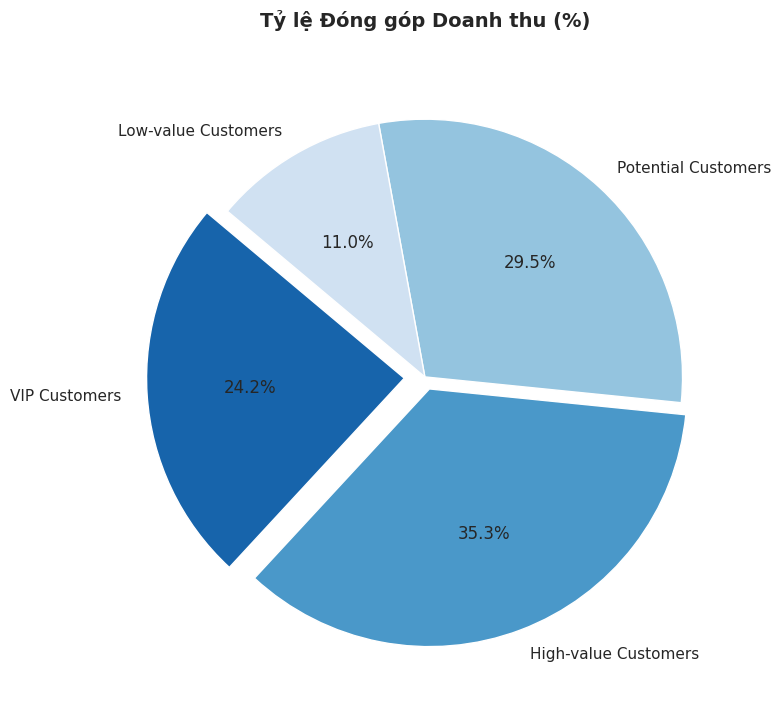

In [29]:
plt.figure(figsize=(8, 8))
plt.pie(
    kpi_ps4['RevenueContribution_%'],
    labels=kpi_ps4['Segment'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Blues_r", len(kpi_ps4)),
    explode=[0.08, 0.05, 0, 0]
)
plt.title('Tỷ lệ Đóng góp Doanh thu (%)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 21.2 — Biểu đồ 2: So sánh Tần suất mua hàng trung bình giữa các nhóm (Bar Chart)


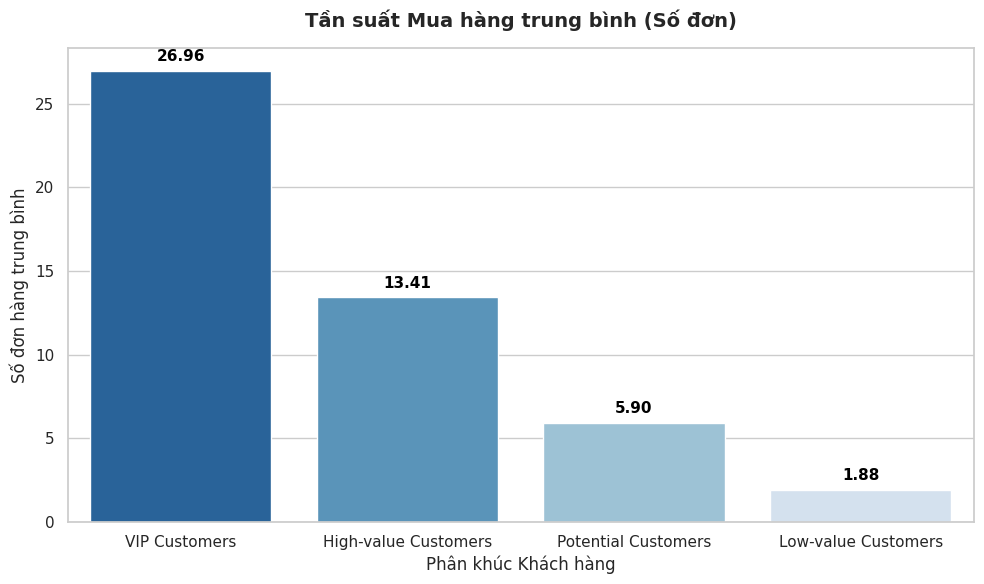

In [30]:
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    x='Segment',
    y='AverageFrequency',
    data=kpi_ps4,
    palette='Blues_r',
    hue='Segment',
    legend=False
)
plt.title('Tần suất Mua hàng trung bình (Số đơn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Phân khúc Khách hàng', fontsize=12)
plt.ylabel('Số đơn hàng trung bình', fontsize=12)

# Hiển thị số liệu chi tiết trên đầu mỗi cột
for p in ax2.patches:
    ax2.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black',
        xytext=(0, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.show()


# 21.3 — Biểu đồ 3: So sánh Khoảng cách giữa các lần mua trung bình giữa các nhóm (Bar Chart)


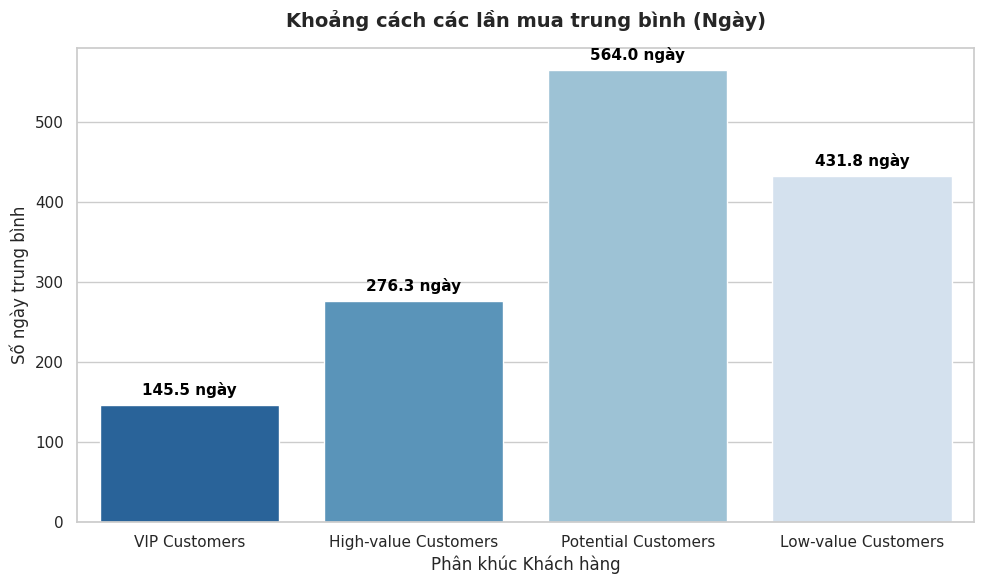

In [31]:
plt.figure(figsize=(10, 6))
ax3 = sns.barplot(
    x='Segment',
    y='AverageInterPurchaseDays',
    data=kpi_ps4,
    palette='Blues_r',
    hue='Segment',
    legend=False
)
plt.title('Khoảng cách các lần mua trung bình (Ngày)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Phân khúc Khách hàng', fontsize=12)
plt.ylabel('Số ngày trung bình', fontsize=12)

# Hiển thị số liệu chi tiết trên đầu mỗi cột
for p in ax3.patches:
    ax3.annotate(
        f"{p.get_height():.1f} ngày",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black',
        xytext=(0, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# 22 — Kiểm tra kết quả

In [32]:
print("Duplicate CustomerID:", customer_analysis["customer_id"].duplicated().sum())
print("Null Segment:", customer_analysis["Segment"].isnull().sum())
print("Tần suất mua nhỏ nhất:", customer_analysis["PurchaseFrequency"].min())
print("Tổng CustomerShare (%):", kpi_ps4["CustomerShare_%"].sum())
print("Tổng RevenueContribution (%):", kpi_ps4["RevenueContribution_%"].sum())
print("Tổng doanh thu toàn hệ thống:", total_revenue)
print("Giá trị trung vị doanh thu:", p50)

Duplicate CustomerID: 0
Null Segment: 0
Tần suất mua nhỏ nhất: 1
Tổng CustomerShare (%): 100.0
Tổng RevenueContribution (%): 100.00000000000001
Tổng doanh thu toàn hệ thống: 12518175747.199999
Giá trị trung vị doanh thu: 79730.85


# 23 — Nhận xét kết quả kinh doanh

- **Hiện tượng Pareto rõ nét**: Nhóm VIP (5%) và High-value (15%) gộp lại tạo thành **Top 20% khách hàng hàng đầu nhưng đóng góp tới ~59.5% tổng doanh thu** của doanh nghiệp.
- **Sự chuyển hóa từ PS1, PS2 & PS3**: Nhóm VIP/High-value có tỷ lệ khách quay lại (`RepeatCustomerRate`) là tuyệt đối **100%**, tần suất mua cực kỳ cao (26.96 lần đối với VIP, 13.41 đối với High-value), và quy mô giỏ hàng vượt trội. Trái lại, nhóm Low-value có tỷ lệ Repeat chỉ đạt **47.96%**, tần suất mua chưa đến 2 lần và AOV thấp nhất.

# 24 — Đề xuất chiến lược chăm sóc và giữ chân khách hàng (Actionable CRM)

- **VIP Customers**: Triển khai các dịch vụ mang tính cá nhân hóa vượt trội (Private CS, VIP Club). Tổ chức sự kiện tri ân đặc quyền hoặc chương trình quà tặng sinh nhật thủ công thiết kế riêng. Thiết lập cổng hỗ trợ giải quyết khiếu nại trong 1 giờ.
- **High-value Customers**: Đẩy mạnh các chiến lược cross-sell/up-sell. Khuyến khích nâng hạng thành viên lên VIP bằng cách tích điểm nhận ưu đãi/voucher mua sắm quy mô lớn.
- **Potential Customers**: Phân tích chu kỳ `InterPurchaseDays` trung bình (~564 ngày) để xây dựng hệ thống gửi thông điệp cá nhân tự động (Automated SMS/Email/App Push) thúc đẩy mua lại đúng nhịp độ tiêu dùng.
- **Low-value Customers**: Tiết kiệm chi phí CRM. Chạy các chiến dịch tiếp thị đại trà (Mass email), định hình các chương trình xả hàng tồn kho hoặc bán kèm combo đồng giá nhằm tăng AOV và giải phóng dung lượng kho.